For using Colab GPU, preprocessed data are saved at Google Drive at Folder ML_project

In [1]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/ML_project/' # For MGA

import numpy as np

# Adjust 'ML_Project' if you named your Drive folder something else!
file_path = drive_path + 'processed_train_data_corr_threshold0.npz'

# Load the preprocessed data
data = np.load(file_path)
x_train_full = data['x'] 
y_train_full = data['y'] 

# Normalize pixel values
x_train_full = x_train_full.astype('float32') / 255.0

print(f"Loaded training data shape: {x_train_full.shape}")



Mounted at /content/drive
Loaded training data shape: (9227, 45, 51, 1)


In [2]:
y_train = y_train_full
X_train = x_train_full

test_data_path = drive_path + 'processed_test_data_corr_threshold0.npz' 
test_data = np.load(test_data_path)
x_test = test_data['x'].astype('float32') / 255.0
test_ids = test_data['ids'].astype(int) - 1 # Adjust IDs to be correctly indexed 



In [3]:
import numpy as np

# --- Model 1 Data (0 vs 1+) ---
# 0 stays 0. Anything > 0 becomes 1.
y_train_1 = (y_train > 0).astype(int)
X_train_1 = X_train # Uses all data

# --- Model 2 Data (1 vs 2+) ---
# Filter out 0s. 
indices_1plus = np.where(y_train > 0)[0]
X_train_2 = X_train[indices_1plus]
# If it's 1 person, target is 0. If it's 2 or 3 persons, target is 1.
y_train_2 = (y_train[indices_1plus] > 1).astype(int) 

# --- Model 3 Data (2 vs 3) ---
# Filter out 0s and 1s.
indices_2plus = np.where(y_train > 1)[0]
X_train_3 = X_train[indices_2plus]
# If it's 2 persons, target is 0. If it's 3 persons, target is 1.
y_train_3 = (y_train[indices_2plus] > 2).astype(int)

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_binary_cnn(input_shape=(45, 51, 1)):
    model = models.Sequential()

    # --- Block 1 ---
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # --- Block 2 ---
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # --- Block 3 ---
    model.add(layers.Conv2D(128, kernel_size=(5, 5), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.1))

    # --- Fully Connected Classifier ---
    
    model.add(layers.Flatten())
    
    
    model.add(layers.Dense(1024))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('gelu'))
    model.add(layers.Dropout(0.25))
    
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.25))

    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5)) 

    # --- Output Layer ---
    # THE CRITICAL FIX: 1 unit with 'sigmoid' (Softmax with 1 unit outputs 1.0 every time)
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_second_binary_cnn(input_shape=(45, 51, 1)):
    model = models.Sequential()

    # --- 1. LIGHT DATA AUGMENTATION (The sweet spot we found) ---

    model.add(layers.GaussianNoise(stddev=0.005))
    model.add(layers.RandomFlip("horizontal"))
    

    # --- 2. CONVOLUTIONAL BLOCKS ---
    model.add(layers.Conv2D(32, kernel_size=(5, 5), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, kernel_size=(5, 5), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.1))

    # --- 3. DEEPER FULLY CONNECTED CLASSIFIER ---
    model.add(layers.Flatten())
    
    model.add(layers.Dense(1024))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('gelu'))
    model.add(layers.Dropout(0.25))
    
    # The crucial extra layer that gave your network more "brain power"
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.25))

    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    
    # Lowered final dropout to 0.3 since we have augmentation now
    model.add(layers.Dropout(0.3)) 

    # --- 4. BINARY OUTPUT ---
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_third_binary_cnn(input_shape=(45, 51, 1)):
    model = models.Sequential()

    # --- Block 1 ---
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # --- Block 2 ---
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # --- Block 3 ---
    model.add(layers.Conv2D(128, kernel_size=(5, 5), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.1))

    # --- Fully Connected Classifier ---
    
    model.add(layers.Flatten())
    
    
    model.add(layers.Dense(1024))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('gelu'))
    model.add(layers.Dropout(0.25))
    
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.25))

    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3)) 

    # --- Output Layer ---
    # THE CRITICAL FIX: 1 unit with 'sigmoid' (Softmax with 1 unit outputs 1.0 every time)
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model



In [7]:
model_1 = build_binary_cnn()
model_1.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:

model_2 = build_second_binary_cnn()
model_2.compile(optimizer=optimizers.Nadam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [9]:
model_3 = build_third_binary_cnn()
model_3.compile(optimizer=optimizers.Nadam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

# Create a single, unified split from your raw dataset
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42
)

# ==========================================
# --- Model 1 Data (0 vs 1+) ---
# ==========================================
X_t1 = X_train_base
y_t1 = (y_train_base > 0).astype(int)

X_v1 = X_val_base
y_v1 = (y_val_base > 0).astype(int)

# ==========================================
# --- Model 2 Data (1 vs 2+) ---
# ==========================================
# Train
idx_t2 = np.where(y_train_base > 0)[0]
X_t2 = X_train_base[idx_t2]
y_t2 = (y_train_base[idx_t2] > 1).astype(int)

# Validation
idx_v2 = np.where(y_val_base > 0)[0]
X_v2 = X_val_base[idx_v2]
y_v2 = (y_val_base[idx_v2] > 1).astype(int)

# ==========================================
# --- Model 3 Data (2 vs 3) ---
# ==========================================
# Train
idx_t3 = np.where(y_train_base > 1)[0]
X_t3 = X_train_base[idx_t3]
y_t3 = (y_train_base[idx_t3] > 2).astype(int)

# Validation
idx_v3 = np.where(y_val_base > 1)[0]
X_v3 = X_val_base[idx_v3]
y_v3 = (y_val_base[idx_v3] > 2).astype(int)



In [11]:
import tensorflow as tf
# 2. Add Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    restore_best_weights=True
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5,      # Cut learning rate in half
    patience=5,      # Wait 5 epochs without improvement before dropping
    min_lr=1e-6,     # Don't let it drop below this
    verbose=1
)

def train_binary_model(model, X_train, y_train, X_val, y_val, batch_size=32, epochs=500):
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True
    )
    
    history = model.fit(
        X_train, y_train, 
        batch_size=batch_size, 
        epochs=epochs, 
        validation_data=(X_val, y_val), 
        callbacks=[early_stopping, reduce_lr]
    )
    return history

print("--- Training Model 1 (0 vs 1+) ---")
hist_1 = train_binary_model(model_1, X_t1, y_t1, X_v1, y_v1)

--- Training Model 1 (0 vs 1+) ---
Epoch 1/500
260/260 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9565 - loss: 0.1435 - val_accuracy: 0.8418 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 2/500
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9913 - loss: 0.0386 - val_accuracy: 0.9848 - val_loss: 0.0570 - learning_rate: 0.0010
Epoch 3/500
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9942 - loss: 0.0210 - val_accuracy: 0.9967 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 4/500
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9978 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 5/500
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9974 - loss: 0.0105 - val_accuracy: 0.9989 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 6/500
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9969 - loss: 0.0108 - val_accuracy: 0.9989 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 7/500
260/260 ━━━━━━━━━━━━━━━━━━━━

In [12]:
print("--- Training Model 2 (1 vs 2+) ---")
# 1. Calculate the exact class weights for Model 2's dataset
total_m2 = len(y_t2)
pos_m2 = np.sum(y_t2) # Number of '2 person' images
neg_m2 = total_m2 - pos_m2 # Number of '1 person' images

weight_for_0 = (1 / neg_m2) * (total_m2 / 2.0)
weight_for_1 = (1 / pos_m2) * (total_m2 / 2.0)

class_weight_m2 = {0: weight_for_0, 1: weight_for_1}

# 2. Add Early Stopping
early_stopping_m2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience= 15,
    restore_best_weights=True
)


reduce_lr_m2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5,      # Cut learning rate in half
    patience=5,      # Wait 5 epochs without improvement before dropping
    min_lr=1e-6,     # Don't let it drop below this
    verbose=1
)

hist_2 = model_2.fit(
    X_t2, y_t2, 
    batch_size=32, 
    epochs=1000, 
    validation_data=(X_v2, y_v2), 
    callbacks=[early_stopping_m2, reduce_lr_m2], # <--- Both callbacks!
    class_weight=class_weight_m2
)

--- Training Model 2 (1 vs 2+) ---
Epoch 1/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.7171 - loss: 0.5528 - val_accuracy: 0.5194 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 2/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8049 - loss: 0.4157 - val_accuracy: 0.5039 - val_loss: 0.9657 - learning_rate: 0.0010
Epoch 3/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8503 - loss: 0.3416 - val_accuracy: 0.7578 - val_loss: 0.5901 - learning_rate: 0.0010
Epoch 4/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8743 - loss: 0.2908 - val_accuracy: 0.8187 - val_loss: 0.4414 - learning_rate: 0.0010
Epoch 5/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8832 - loss: 0.2763 - val_accuracy: 0.8821 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 6/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9002 - loss: 0.2444 - val_accuracy: 0.8990 - val_loss: 0.2334 - learning_rate: 0.0010
Epoch 7/1000
219/219 ━━━━━━━━━━━━━

In [13]:
print("--- Training Model 3 (2 vs 3) ---")
# 1. Calculate the exact class weights for Model 3's dataset
total_m3 = len(y_t3)
pos_m3 = np.sum(y_t3) # Number of '3 person' images
neg_m3 = total_m3 - pos_m3 # Number of '2 person' images

weight_for_0 = (1 / neg_m3) * (total_m3 / 2.0)
weight_for_1 = (1 / pos_m3) * (total_m3 / 2.0)

class_weight_m3 = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for Class 2 (0): {weight_for_0:.2f}")
print(f"Weight for Class 3 (1): {weight_for_1:.2f}")

# Create a fresh, independent callback that watches accuracy instead of loss
early_stopping_m3 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', # <--- Changed from val_loss
    mode='max',             # <--- We want the highest accuracy
    patience=20, 
    restore_best_weights=True
)

reduce_lr_m3 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6
)

print("--- Training Model 3 (2 vs 3) ---")
hist_3 = model_3.fit(
    X_t3, y_t3, 
    batch_size=32, 
    epochs=100, 
    validation_data=(X_v3, y_v3), 
    callbacks=[early_stopping_m3, reduce_lr_m3], # <--- Use the new callbacks
    class_weight=class_weight_m3
)

--- Training Model 3 (2 vs 3) ---
Weight for Class 2 (0): 0.66
Weight for Class 3 (1): 2.04
--- Training Model 3 (2 vs 3) ---
Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.8015 - loss: 0.3900 - val_accuracy: 0.7494 - val_loss: 0.6122 - learning_rate: 0.0010
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8399 - loss: 0.3088 - val_accuracy: 0.7494 - val_loss: 0.4979 - learning_rate: 0.0010
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8697 - loss: 0.2718 - val_accuracy: 0.7984 - val_loss: 0.3687 - learning_rate: 0.0010
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8906 - loss: 0.2299 - val_accuracy: 0.8605 - val_loss: 0.2863 - learning_rate: 0.0010
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9120 - loss: 0.2066 - val_accuracy: 0.9070 - val_loss: 0.2036 - learning_rate: 0.0010
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9145 - loss: 0.1920 - val_accuracy

In [14]:
import numpy as np

def predict_pipeline(x_data, models, thresholds=(0.5, 0.5, 0.5), verbose=0):
    """
    Runs a 3-stage binary cascade CNN pipeline.
    
    Args:
        x_data: The input numpy array of images/radar frames.
        models: A tuple of (model_1, model_2, model_3).
        thresholds: A tuple of (threshold_1, threshold_2, threshold_3).
        verbose: 1 to print stage progress, 0 for silent execution.
        
    Returns:
        A 1D numpy array of final predicted classes (0, 1, 2, or 3).
    """
    model_1, model_2, model_3 = models
    t1, t2, t3 = thresholds
    
    # Everyone defaults to '0 persons' initially
    predicted_classes = np.zeros(len(x_data), dtype=int)
    original_indices = np.arange(len(x_data))

    if verbose: print(f"Stage 1 (Threshold {t1}): Is someone there? (0 vs 1+)...")
    prob_1 = model_1.predict(x_data, verbose=verbose)
    idx_1plus = original_indices[(prob_1 > t1).flatten()]

    if len(idx_1plus) > 0:
        predicted_classes[idx_1plus] = 1 
        
        if verbose: print(f"Stage 2 (Threshold {t2}): Are there 2+ people? Evaluating {len(idx_1plus)} frames...")
        prob_2 = model_2.predict(x_data[idx_1plus], verbose=verbose)
        idx_2plus = idx_1plus[(prob_2 > t2).flatten()]
        
        if len(idx_2plus) > 0:
            predicted_classes[idx_2plus] = 2
            
            if verbose: print(f"Stage 3 (Threshold {t3}): Are there 3 people? Evaluating {len(idx_2plus)} frames...")
            prob_3 = model_3.predict(x_data[idx_2plus], verbose=verbose)
            idx_3 = idx_2plus[(prob_3 > t3).flatten()]
            print(f"DEBUG: Max probability from Model 3: {np.max(prob_3)}")
            print(f"DEBUG: Count of images > threshold {t3}: {np.sum(prob_3 > t3)}")
            
            if len(idx_3) > 0:
                predicted_classes[idx_3] = 3
                
    return predicted_classes

In [15]:
import os
import pandas as pd

# ==========================================
# --- KAGGLE INFERENCE ---
# ==========================================
print("Running final Kaggle predictions...")

# Set your best thresholds found during testing
best_thresholds = (0.5, 0.5, 0.5) 
my_models = (model_1, model_2, model_3)

# Run the pipeline
predicted_classes = predict_pipeline(x_test, my_models, thresholds=best_thresholds, verbose=1)

# ==========================================
# --- KAGGLE SUBMISSION SAVING ---
# ==========================================

# (Optional) Calculate an estimated accuracy to save in the filename
val_acc_1 = hist_1.history['val_accuracy'][-1]
val_acc_2 = hist_2.history['val_accuracy'][-1]
val_acc_3 = hist_3.history['val_accuracy'][-1]
combined_val_acc = val_acc_1 * val_acc_2 * val_acc_3
print(f"✅ Pipeline predictions complete. Estimated pipeline accuracy: {combined_val_acc:.4f}")

# Create and save submission
submission_df = pd.DataFrame({'id': test_ids, 'target': predicted_classes})
existing_files = [f for f in os.listdir(drive_path) if f.startswith('my_kaggle_submission')]
submission_index = len(existing_files) + 1

v_acc_str = f"{combined_val_acc*100:.2f}".replace('.', '-') 
file_path = f'{drive_path}my_kaggle_submission_{str(submission_index).zfill(3)}_Vacc_{v_acc_str}.csv'

submission_df.to_csv(file_path, index=False)
print(f"✅ Submission successfully saved to your Google Drive at: {file_path}")

Running final Kaggle predictions...
Stage 1 (Threshold 0.5): Is someone there? (0 vs 1+)...
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
Stage 2 (Threshold 0.5): Are there 2+ people? Evaluating 3358 frames...
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Stage 3 (Threshold 0.5): Are there 3 people? Evaluating 1706 frames...
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
DEBUG: Max probability from Model 3: 0.9999959468841553
DEBUG: Count of images > threshold 0.5: 416
✅ Pipeline predictions complete. Estimated pipeline accuracy: 0.9567
✅ Submission successfully saved to your Google Drive at: /content/drive/MyDrive/ML_project/my_kaggle_submission_049_Vacc_95-67.csv


Stage 1 (Threshold 0.5): Is someone there? (0 vs 1+)...
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Stage 2 (Threshold 0.5): Are there 2+ people? Evaluating 7767 frames...
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Stage 3 (Threshold 0.5): Are there 3 people? Evaluating 3962 frames...
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
DEBUG: Max probability from Model 3: 0.9999977350234985
DEBUG: Count of images > threshold 0.5: 967

✅ Overall Pipeline Macro F1 Score: 0.9929


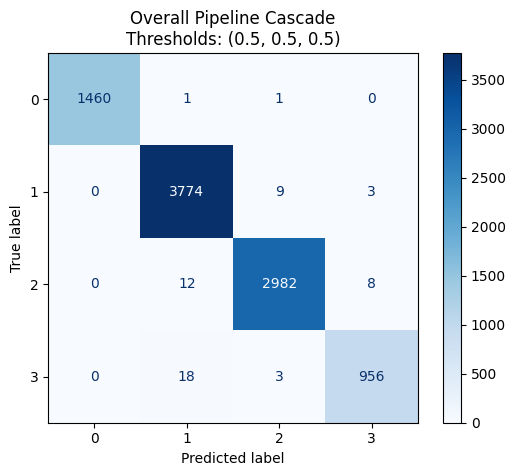

In [16]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Group your models
my_models = (model_1, model_2, model_3)

# Test a custom threshold combination!
# Example: Let's make Model 2 more strict (0.7) to reduce those False Positives
custom_thresholds = (0.5, 0.5, 0.5)

# Get predictions for the whole pipeline
final_preds = predict_pipeline(x_train_full, my_models, thresholds=custom_thresholds, verbose=1)

# Calculate Overall F1 Score (macro averages across all 4 classes)
overall_f1 = f1_score(y_train_full, final_preds, average='macro')
print(f"\n✅ Overall Pipeline Macro F1 Score: {overall_f1:.4f}")

# Display the Final Combined Confusion Matrix
cm = confusion_matrix(y_train_full, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2', '3'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Overall Pipeline Cascade\nThresholds: {custom_thresholds}')
plt.show()

In [17]:
from sklearn.metrics import f1_score

# Now you can use predict_pipeline on a completely uncompromised validation set
my_models = (model_1, model_2, model_3)
val_predictions = predict_pipeline(X_val_base, my_models, thresholds=(0.5, 0.5, 0.5), verbose=0)

overall_f1 = f1_score(y_val_base, val_predictions, average='macro')
print(f"\n✅ True Overall Pipeline Macro F1 Score: {overall_f1:.4f}")

DEBUG: Max probability from Model 3: 0.9999977350234985
DEBUG: Count of images > threshold 0.5: 95

✅ True Overall Pipeline Macro F1 Score: 0.9711


Stage 1 (Threshold 0.5): Is someone there? (0 vs 1+)...
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Stage 2 (Threshold 0.5): Are there 2+ people? Evaluating 7767 frames...
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Stage 3 (Threshold 0.5): Are there 3 people? Evaluating 3962 frames...
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
DEBUG: Max probability from Model 3: 0.9999977350234985
DEBUG: Count of images > threshold 0.5: 967

✅ Overall Pipeline Macro F1 Score: 0.9929


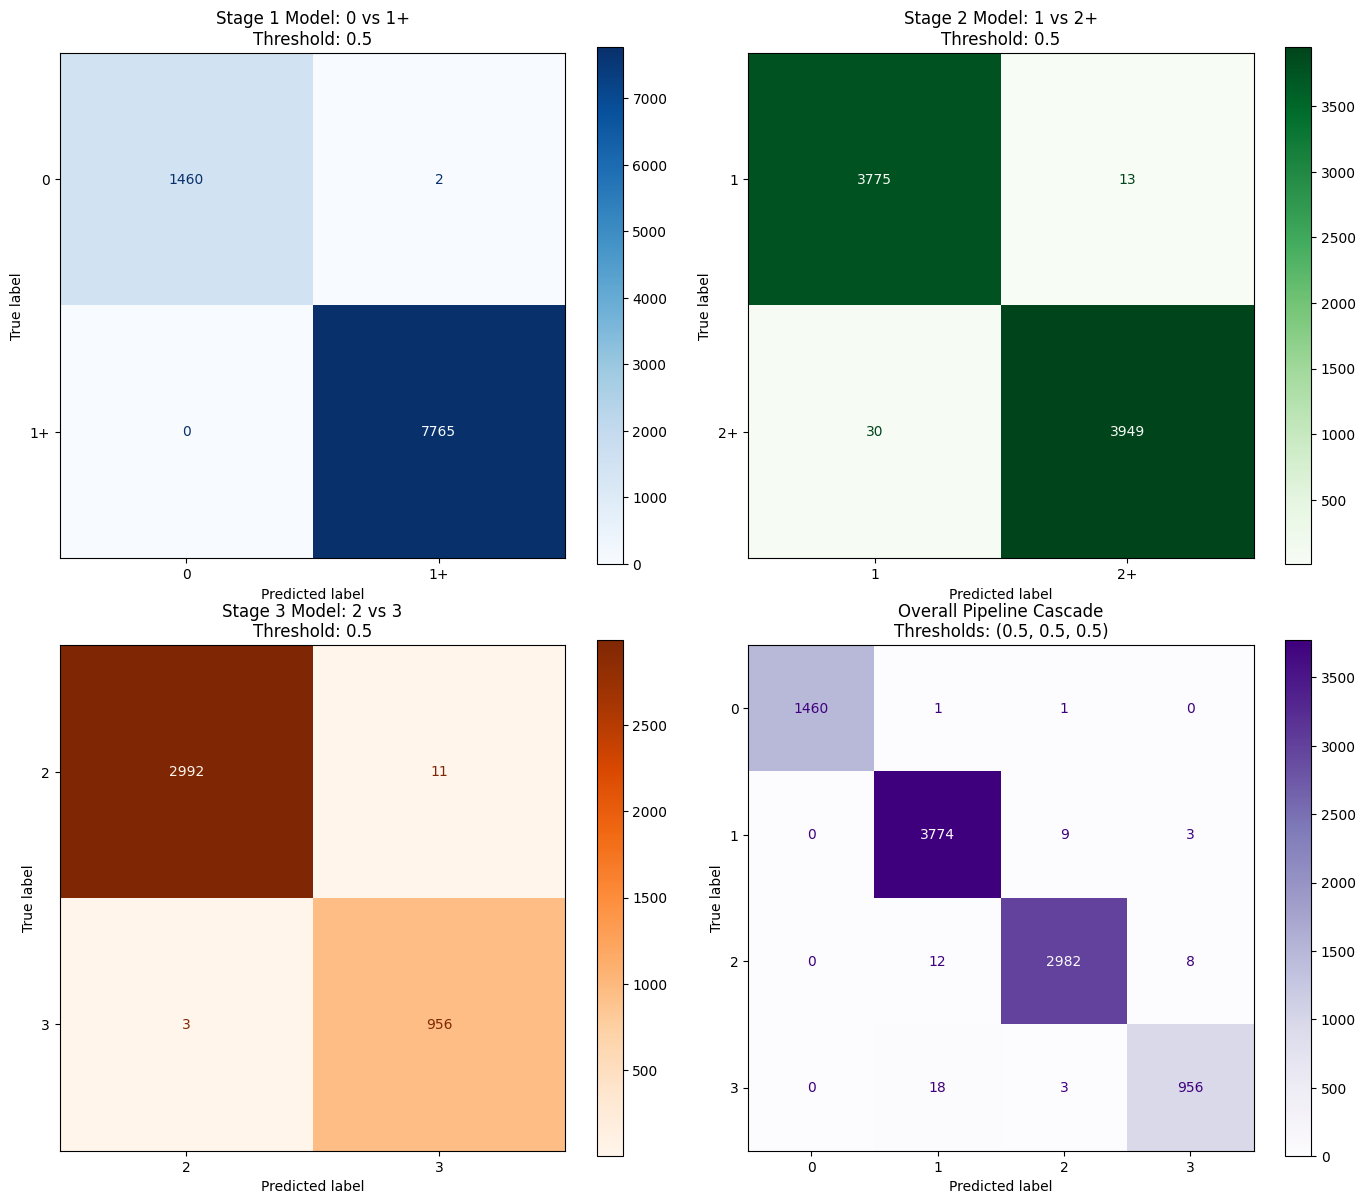

In [18]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Seskupení modelů a nastavení prahů
my_models = (model_1, model_2, model_3)
custom_thresholds = (0.5, 0.5, 0.50)
t1, t2, t3 = custom_thresholds

# 1. Získání predikcí z celé pipeline
final_preds = predict_pipeline(x_train_full, my_models, thresholds=custom_thresholds, verbose=1)

# Celkové F1 skóre
overall_f1 = f1_score(y_train_full, final_preds, average='macro')
print(f"\n✅ Overall Pipeline Macro F1 Score: {overall_f1:.4f}")

# =====================================================================
# 2. Rekonstrukce jednotlivých fází pro individuální konfuzní matice
# =====================================================================

# Fáze 1: Model 1 (0 osob vs. 1 a více) - Běží na celém datasetu
y_true_1 = (y_train_full > 0).astype(int)  # 0 zůstane 0, vše ostatní je 1
prob_1 = model_1.predict(x_train_full, verbose=0)
y_pred_1 = (prob_1 > t1).astype(int).flatten()
idx_1plus = np.where(y_pred_1 == 1)[0]     # Indexy, co projdou do další fáze

# Fáze 2: Model 2 (1 osoba vs. 2 a více) - Běží jen na datech z Fáze 1
if len(idx_1plus) > 0:
    y_true_2 = (y_train_full[idx_1plus] > 1).astype(int)
    prob_2 = model_2.predict(x_train_full[idx_1plus], verbose=0)
    y_pred_2 = (prob_2 > t2).astype(int).flatten()
    idx_2plus = idx_1plus[y_pred_2 == 1]   # Indexy, co projdou do další fáze
else:
    y_true_2, y_pred_2, idx_2plus = [], [], []

# Fáze 3: Model 3 (2 osoby vs. 3 osoby) - Běží jen na datech z Fáze 2
if len(idx_2plus) > 0:
    y_true_3 = (y_train_full[idx_2plus] > 2).astype(int)
    prob_3 = model_3.predict(x_train_full[idx_2plus], verbose=0)
    y_pred_3 = (prob_3 > t3).astype(int).flatten()
else:
    y_true_3, y_pred_3 = [], []


# =====================================================================
# 3. Vykreslení všech matic do jednoho obrázku
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Model 1 CM ---
if len(y_true_1) > 0:
    cm1 = confusion_matrix(y_true_1, y_pred_1)
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['0', '1+'])
    disp1.plot(cmap=plt.cm.Blues, ax=axes[0, 0])
axes[0, 0].set_title(f'Stage 1 Model: 0 vs 1+\nThreshold: {t1}')

# --- Model 2 CM ---
if len(y_true_2) > 0:
    cm2 = confusion_matrix(y_true_2, y_pred_2)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['1', '2+'])
    disp2.plot(cmap=plt.cm.Greens, ax=axes[0, 1])
axes[0, 1].set_title(f'Stage 2 Model: 1 vs 2+\nThreshold: {t2}')

# --- Model 3 CM ---
if len(y_true_3) > 0:
    cm3 = confusion_matrix(y_true_3, y_pred_3)
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['2', '3'])
    disp3.plot(cmap=plt.cm.Oranges, ax=axes[1, 0])
axes[1, 0].set_title(f'Stage 3 Model: 2 vs 3\nThreshold: {t3}')

# --- Overall Pipeline CM ---
cm_overall = confusion_matrix(y_train_full, final_preds)
disp_overall = ConfusionMatrixDisplay(confusion_matrix=cm_overall, display_labels=['0', '1', '2', '3'])
disp_overall.plot(cmap=plt.cm.Purples, ax=axes[1, 1])
axes[1, 1].set_title(f'Overall Pipeline Cascade\nThresholds: {custom_thresholds}')


plt.tight_layout()
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


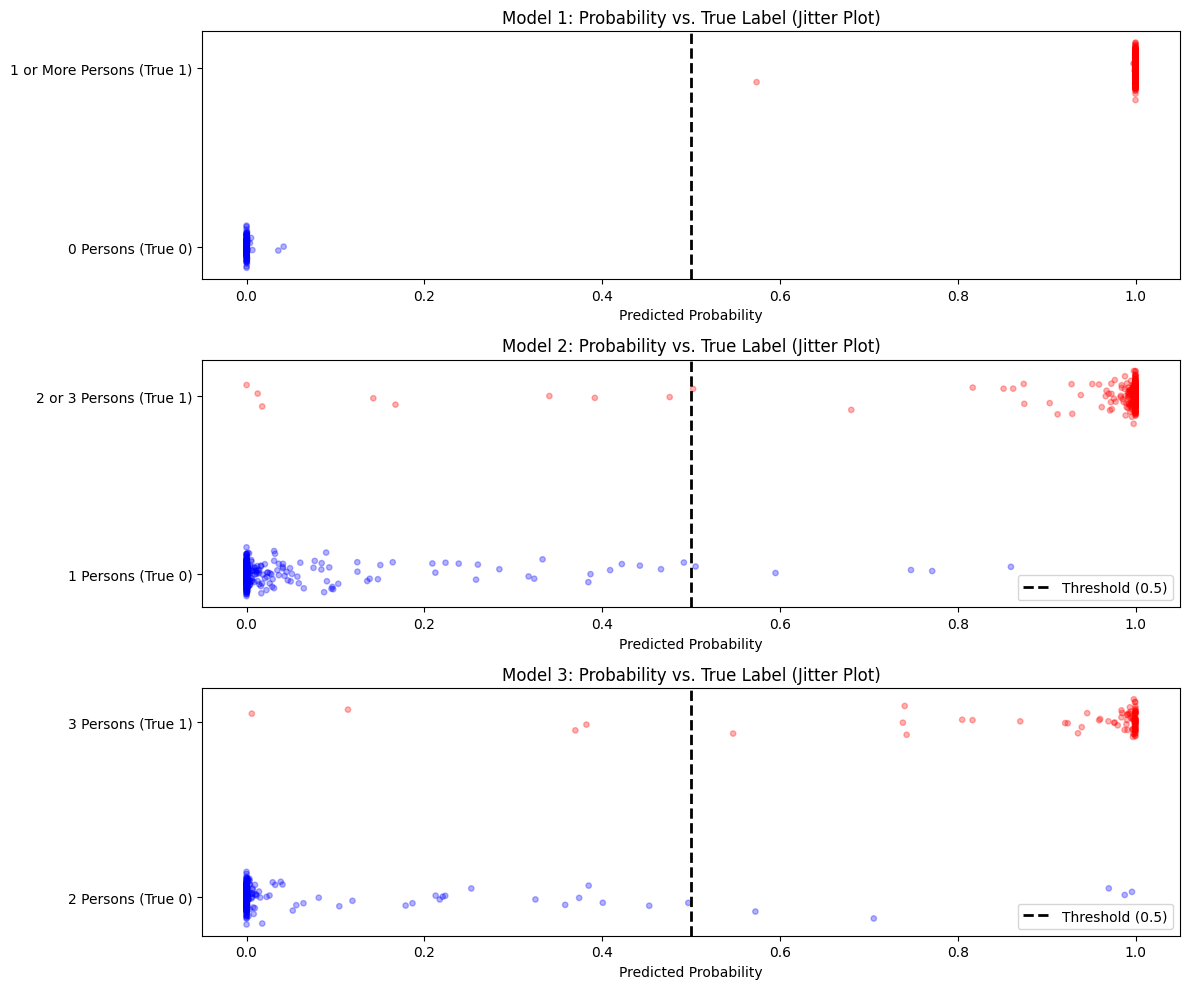

In [19]:
prob_1 = model_1.predict(X_v1).flatten()
prob_2 = model_2.predict(X_v2).flatten()
prob_3 = model_3.predict(X_v3).flatten()
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 3, 3]})

# --- PLOT 1: The Scatter Plot you asked for ---
# We add a tiny bit of random noise (jitter) to the Y-axis so the dots don't all stack on top of each other
jitter = np.random.normal(0, 0.05, size=len(y_v1))

ax1.scatter(prob_1, y_v1 + jitter, alpha=0.3, s=15, c=y_v1, cmap='bwr')
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['0 Persons (True 0)', '1 or More Persons (True 1)'])
ax1.set_xlabel("Predicted Probability")
ax1.set_title("Model 1: Probability vs. True Label (Jitter Plot)")


jitter = np.random.normal(0, 0.05, size=len(y_v2))

ax2.scatter(prob_2, y_v2 + jitter, alpha=0.3, s=15, c=y_v2, cmap='bwr')
ax2.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['1 Persons (True 0)', '2 or 3 Persons (True 1)'])
ax2.set_xlabel("Predicted Probability")
ax2.set_title("Model 2: Probability vs. True Label (Jitter Plot)")
ax2.legend()

jitter = np.random.normal(0, 0.05, size=len(y_v3))

ax3.scatter(prob_3, y_v3 + jitter, alpha=0.3, s=15, c=y_v3, cmap='bwr')
ax3.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['2 Persons (True 0)', '3 Persons (True 1)'])
ax3.set_xlabel("Predicted Probability")
ax3.set_title("Model 3: Probability vs. True Label (Jitter Plot)")
ax3.legend()

plt.tight_layout()
plt.show()

DEBUG: Max probability from Model 3: 0.9999977350234985
DEBUG: Count of images > threshold 0.5: 967
Total misclassified images: 55


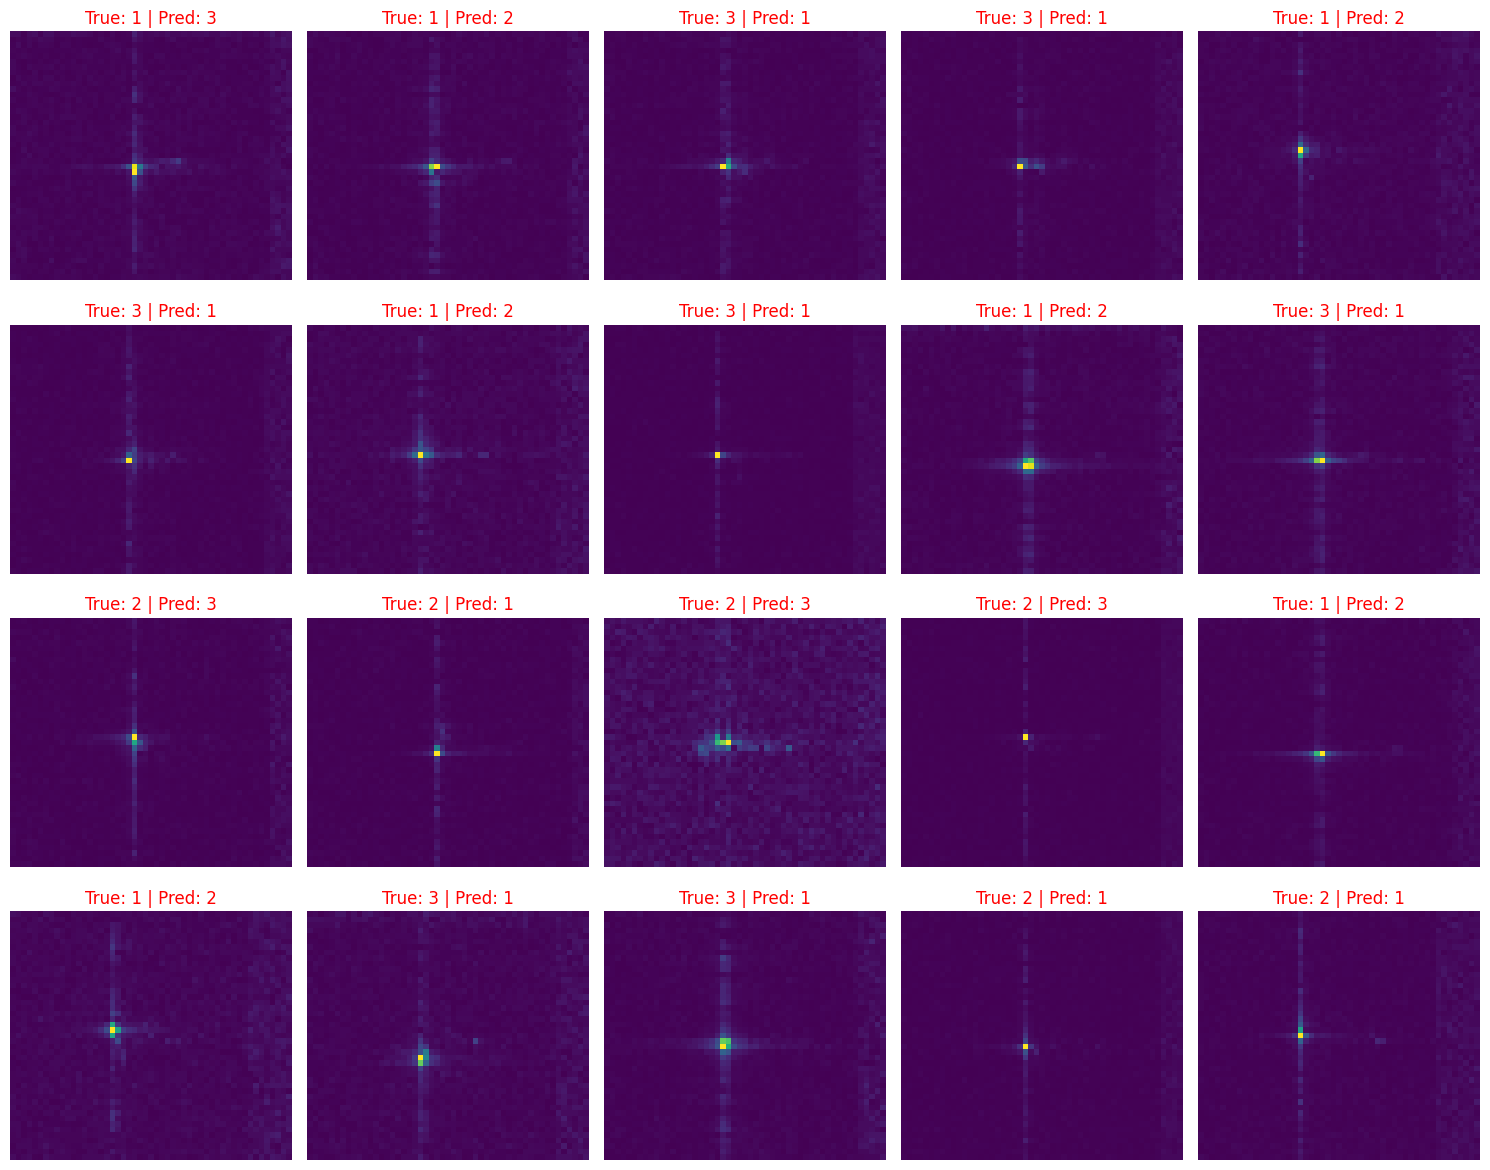

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have:
# x_test_data : Your input radar images
# y_true_full : The actual correct classes (0, 1, 2, or 3)
# final_preds : The predicted classes from your predict_pipeline()
final_preds = predict_pipeline(x_train_full, my_models, thresholds=custom_thresholds, verbose=0)
# 1. Find the indices where the prediction was wrong
misclassified_idx = np.where(y_train_full != final_preds)[0]
print(f"Total misclassified images: {len(misclassified_idx)}")

# 2. Plot up to 20 misclassified images
num_to_plot = min(len(misclassified_idx), 20)
fig, axes = plt.subplots(4, 5, figsize=(15, 12)) 
axes = axes.flatten()

for i, idx in enumerate(misclassified_idx[:num_to_plot]):
    ax = axes[i]
    # x_test_data is shape (51, 45, 1). We use .squeeze() to make it (51, 45) for plotting
    ax.imshow(x_train_full[idx].squeeze(), cmap='viridis') # return original colormap for better visibility
    
    true_label = y_train_full[idx]
    pred_label = final_preds[idx]
    
    # Title shows the mistake: e.g., "True: 3 | Pred: 2"
    ax.set_title(f"True: {true_label} | Pred: {pred_label}", 
                 color='red' if true_label != pred_label else 'black')
    ax.axis('off')

# Hide any unused subplots if there are fewer than 20 mistakes
for j in range(num_to_plot, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Confusion matrices at validation set

Stage 1 (Threshold 0.5): Is someone there? (0 vs 1+)...
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Stage 2 (Threshold 0.5): Are there 2+ people? Evaluating 772 frames...
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Stage 3 (Threshold 0.5): Are there 3 people? Evaluating 384 frames...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
DEBUG: Max probability from Model 3: 0.9999977350234985
DEBUG: Count of images > threshold 0.5: 95

✅ Overall Pipeline Macro F1 Score: 0.9711


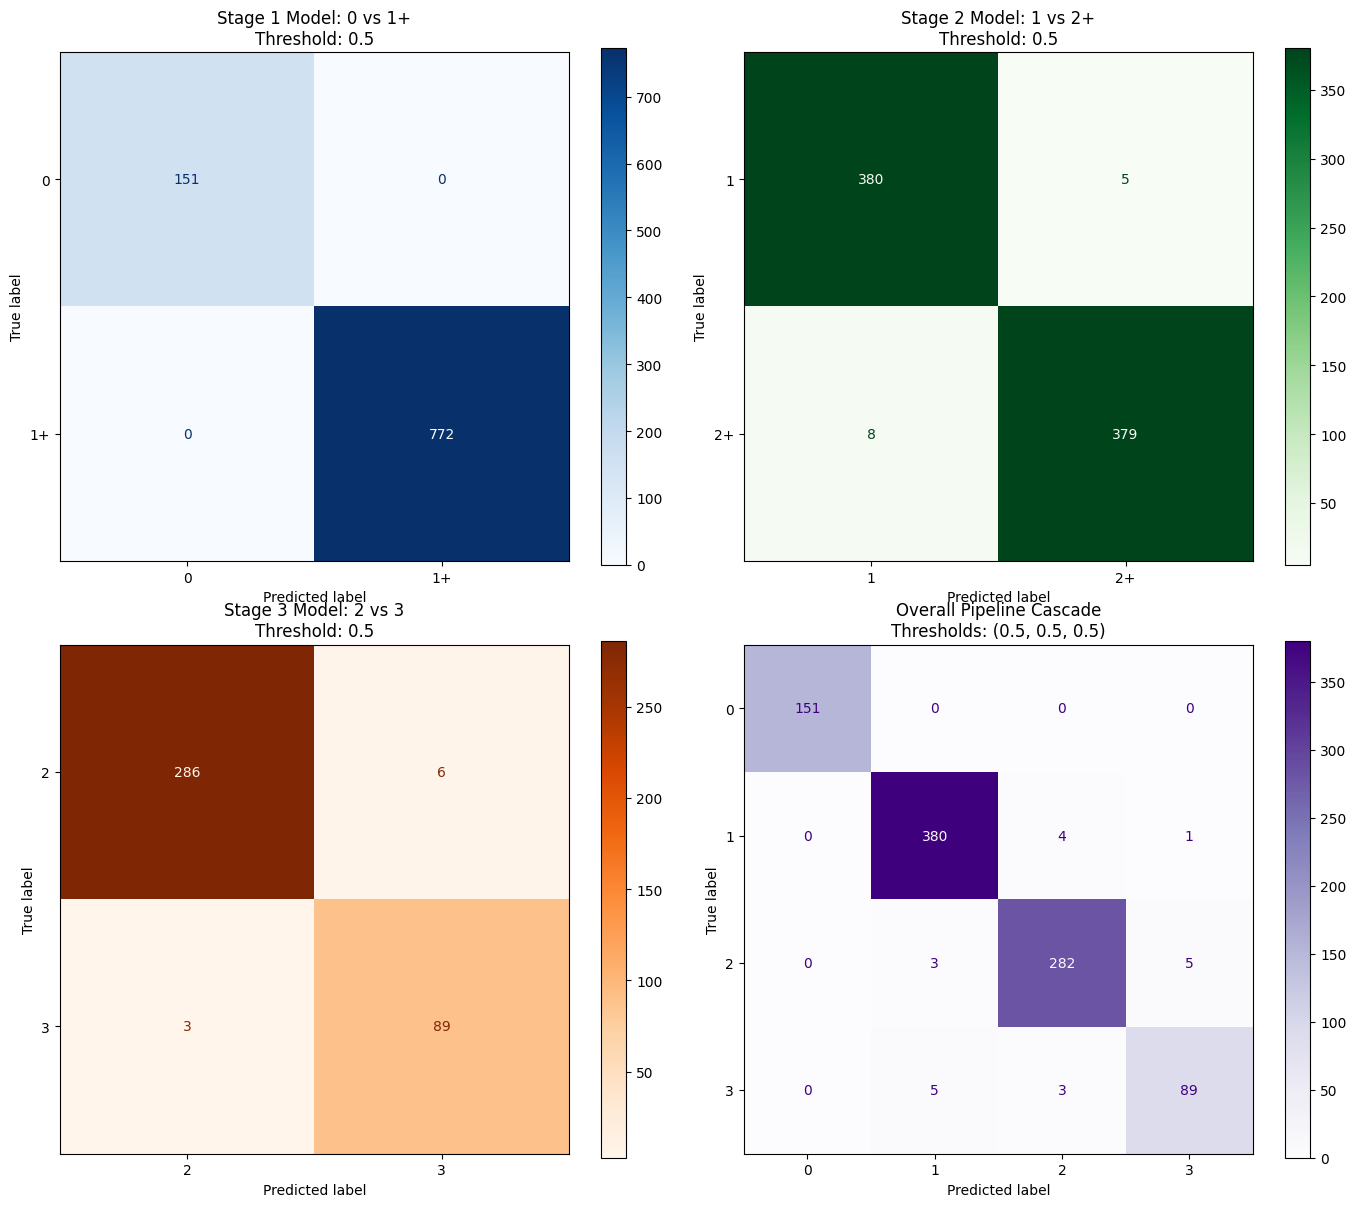

In [23]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Seskupení modelů a nastavení prahů
my_models = (model_1, model_2, model_3)
custom_thresholds = (0.5, 0.5, 0.50)
t1, t2, t3 = custom_thresholds

# 1. Získání predikcí z celé pipeline
final_preds = predict_pipeline(X_val_base, my_models, thresholds=custom_thresholds, verbose=1)

# Celkové F1 skóre
overall_f1 = f1_score(y_val_base, final_preds, average='macro')
print(f"\n✅ Overall Pipeline Macro F1 Score: {overall_f1:.4f}")

# =====================================================================
# 2. Rekonstrukce jednotlivých fází pro individuální konfuzní matice
# =====================================================================

# Fáze 1: Model 1 (0 osob vs. 1 a více) - Běží na celém datasetu
y_true_1 = (y_val_base > 0).astype(int)  # 0 zůstane 0, vše ostatní je 1
prob_1 = model_1.predict(X_val_base, verbose=0)
y_pred_1 = (prob_1 > t1).astype(int).flatten()
idx_1plus = np.where(y_pred_1 == 1)[0]     # Indexy, co projdou do další fáze

# Fáze 2: Model 2 (1 osoba vs. 2 a více) - Běží jen na datech z Fáze 1
if len(idx_1plus) > 0:
    y_true_2 = (y_val_base[idx_1plus] > 1).astype(int)
    prob_2 = model_2.predict(X_val_base[idx_1plus], verbose=0)
    y_pred_2 = (prob_2 > t2).astype(int).flatten()
    idx_2plus = idx_1plus[y_pred_2 == 1]   # Indexy, co projdou do další fáze
else:
    y_true_2, y_pred_2, idx_2plus = [], [], []

# Fáze 3: Model 3 (2 osoby vs. 3 osoby) - Běží jen na datech z Fáze 2
if len(idx_2plus) > 0:
    y_true_3 = (y_val_base[idx_2plus] > 2).astype(int)
    prob_3 = model_3.predict(X_val_base[idx_2plus], verbose=0)
    y_pred_3 = (prob_3 > t3).astype(int).flatten()
else:
    y_true_3, y_pred_3 = [], []


# =====================================================================
# 3. Vykreslení všech matic do jednoho obrázku
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Model 1 CM ---
if len(y_true_1) > 0:
    cm1 = confusion_matrix(y_true_1, y_pred_1)
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['0', '1+'])
    disp1.plot(cmap=plt.cm.Blues, ax=axes[0, 0])
axes[0, 0].set_title(f'Stage 1 Model: 0 vs 1+\nThreshold: {t1}')

# --- Model 2 CM ---
if len(y_true_2) > 0:
    cm2 = confusion_matrix(y_true_2, y_pred_2)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['1', '2+'])
    disp2.plot(cmap=plt.cm.Greens, ax=axes[0, 1])
axes[0, 1].set_title(f'Stage 2 Model: 1 vs 2+\nThreshold: {t2}')

# --- Model 3 CM ---
if len(y_true_3) > 0:
    cm3 = confusion_matrix(y_true_3, y_pred_3)
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['2', '3'])
    disp3.plot(cmap=plt.cm.Oranges, ax=axes[1, 0])
axes[1, 0].set_title(f'Stage 3 Model: 2 vs 3\nThreshold: {t3}')

# --- Overall Pipeline CM ---
cm_overall = confusion_matrix(y_val_base, final_preds)
disp_overall = ConfusionMatrixDisplay(confusion_matrix=cm_overall, display_labels=['0', '1', '2', '3'])
disp_overall.plot(cmap=plt.cm.Purples, ax=axes[1, 1])
axes[1, 1].set_title(f'Overall Pipeline Cascade\nThresholds: {custom_thresholds}')


plt.tight_layout()
plt.show()